# Fase 3 — Calibración conservadora por cuantiles y coste económico
### TFM: Arquitectura de Mantenimiento Predictivo

El modelo de flota predice la **media** del RUL: se equivoca por arriba y por abajo casi por
igual (vimos ~54% de motores sobreestimados). Pero los dos errores **no cuestan lo mismo**:

- **Subestimar** el RUL → mantenimiento un poco prematuro → coste acotado (vida útil
  desaprovechada).
- **Sobreestimar** el RUL → dejas volando un motor que debía estar en tierra → avería no
  programada o, en el peor caso, fallo en vuelo → coste mucho mayor (económico y de seguridad).

Aquí calibramos el modelo para que se equivoque por el lado **seguro y barato**, usando
**regresión por cuantiles**: en vez de pedir la media, pedimos un percentil bajo (p.ej. el 10),
de modo que el modelo da una estimación prudente ("con 90% de confianza, le quedan al menos N
ciclos"). Comparamos el modelo estándar con dos niveles conservadores y lo traducimos a **coste
esperado** con una función de coste asimétrica configurable.

Esto es el puente con la justificación económica del TFM: el objetivo no es minimizar el error
simétrico (RMSE), sino el **coste esperado real**, que pondera mucho más el error caro.

Autocontenido. ~25-30 min (la flota se construye una vez; se entrenan 3 modelos sobre ella).

In [1]:
import os, time, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt, h5py
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GroupShuffleSplit
import xgboost as xgb
warnings.filterwarnings('ignore')

SEED = 42; SUBSAMPLE = 25; EVAL_SUBSAMPLE = 10; RUL_CAP = 57
ROLL_WINDOWS = (5, 10); SLOPE_W = 10
QUANTILES = [0.25, 0.10]          # niveles conservadores a probar (además del modelo estándar)
COST_LATE, COST_EARLY = 10.0, 1.0 # coste relativo: sobreestimar (tarde) cuesta 10x subestimar
np.random.seed(SEED)

FILES = {
    'DS01':'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS01-005.h5',
    'DS02':'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS02-006.h5',
    'DS03':'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS03-012.h5',
    'DS04':'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS04.h5',
    'DS05':'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS05.h5',
    'DS06':'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS06.h5',
    'DS07':'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS07.h5',
    'DS08a':'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS08a-009.h5',
    'DS08c':'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS08c-008.h5',
}
DS_CODE = {name: i for i, name in enumerate(FILES)}
present = [n for n, p in FILES.items() if os.path.exists(p)]
print('Presentes:', present)
print(f'Coste asimétrico: sobreestimar = {COST_LATE}x, subestimar = {COST_EARLY}x')

Presentes: ['DS01', 'DS02', 'DS03', 'DS04', 'DS05', 'DS06', 'DS07', 'DS08a', 'DS08c']
Coste asimétrico: sobreestimar = 10.0x, subestimar = 1.0x


## 1. Cargador, features y utilidades (mismo pipeline)

In [2]:
def load_subset(path, split, name):
    with h5py.File(path, 'r') as f:
        W=np.array(f[f'W_{split}'],dtype=np.float32); X_s=np.array(f[f'X_s_{split}'],dtype=np.float32)
        A=np.array(f[f'A_{split}'],dtype=np.float32); Y=np.array(f[f'Y_{split}'],dtype=np.float32)
        W_var=[v.decode() for v in f['W_var'][:]]; Xs_var=[v.decode() for v in f['X_s_var'][:]]
        A_var=[v.decode() for v in f['A_var'][:]]
    if 'hs' in A_var:
        i=A_var.index('hs'); A=np.delete(A,i,axis=1); A_var=[v for v in A_var if v!='hs']
    df=pd.DataFrame(np.hstack([A,W,X_s,Y.reshape(-1,1)]), columns=A_var+W_var+Xs_var+['RUL'])
    for c in ['unit','cycle','Fc']: df[c]=df[c].astype(int)
    df['dataset']=name; df['ds_code']=DS_CODE[name]; df['engine_id']=name+'_u'+df['unit'].astype(str)
    return df, W_var, Xs_var

def cycle_level_features(df, sensors, windows=ROLL_WINDOWS, slope_w=SLOPE_W):
    df=df.sort_values(['engine_id','cycle'])
    cyc=df.groupby(['engine_id','cycle'])[sensors].mean().reset_index().sort_values(['engine_id','cycle'])
    rc=[]
    for w in windows:
        for col in sensors:
            cyc[f'{col}_roll{w}_mean']=cyc.groupby('engine_id')[col].transform(lambda x:x.rolling(w,min_periods=1).mean())
            cyc[f'{col}_roll{w}_std'] =cyc.groupby('engine_id')[col].transform(lambda x:x.rolling(w,min_periods=1).std().fillna(0))
            rc+=[f'{col}_roll{w}_mean',f'{col}_roll{w}_std']
    def slope(x,w):
        a=x.values; out=np.zeros(len(a))
        for i in range(len(a)):
            seg=a[max(0,i-w+1):i+1]
            if len(seg)>=2: out[i]=np.polyfit(np.arange(len(seg)),seg,1)[0]
        return pd.Series(out,index=x.index)
    for col in sensors:
        cyc[f'{col}_slope{slope_w}']=cyc.groupby('engine_id')[col].transform(lambda x:slope(x,slope_w)); rc.append(f'{col}_slope{slope_w}')
    stats=df.groupby(['engine_id','cycle'])[sensors].agg(['max','std'])
    stats.columns=[f'{s}_cyc_{a}' for s,a in stats.columns]; stats=stats.fillna(0.0).reset_index()
    return cyc[['engine_id','cycle']+rc].merge(stats,on=['engine_id','cycle'])

def add_pos_relativa(df):
    df=df.sort_values(['engine_id','cycle']).reset_index(drop=True)
    pos=df.groupby(['engine_id','cycle']).cumcount()
    size=df.groupby(['engine_id','cycle'])['cycle'].transform('size')-1
    df['pos_relativa']=(pos/size.replace(0,1)).astype(np.float32); return df

def assemble(df, cyc_feat, sensors, w_var, subsample=None):
    df=add_pos_relativa(df)
    keep=['engine_id','dataset','ds_code','unit','cycle','Fc','RUL']+sensors+w_var+['pos_relativa']
    obs=df[keep]
    if subsample: obs=obs.sample(frac=1.0/subsample,random_state=SEED)
    obs=obs.copy(); obs['age']=obs['cycle'].astype(np.float32)
    return obs.merge(cyc_feat,on=['engine_id','cycle'],how='left')

def nasa_score(yr, yp):
    d=np.asarray(yp)-np.asarray(yr)
    return float(np.sum(np.where(d<0, np.exp(-d/13)-1, np.exp(d/10)-1)))

In [3]:
SENSORS, WVARS, FEATURES = None, None, None
def _set_schema(Xv, Wv):
    global SENSORS, WVARS, FEATURES
    SENSORS, WVARS = Xv, Wv
    cyc=[]
    for w in ROLL_WINDOWS:
        for s in SENSORS: cyc+=[f'{s}_roll{w}_mean',f'{s}_roll{w}_std']
    for s in SENSORS: cyc+=[f'{s}_slope{SLOPE_W}']
    for s in SENSORS: cyc+=[f'{s}_cyc_max',f'{s}_cyc_std']
    FEATURES = SENSORS+WVARS+['pos_relativa','age','Fc','ds_code']+cyc

def build_train(subsets, subsample=SUBSAMPLE):
    parts=[]
    for name in subsets:
        if not os.path.exists(FILES[name]): continue
        df,Wv,Xv=load_subset(FILES[name],'dev',name)
        if SENSORS is None: _set_schema(Xv,Wv)
        cyc=cycle_level_features(df,SENSORS)
        parts.append(assemble(df,cyc,SENSORS,WVARS,subsample=subsample)); del df,cyc
    return pd.concat(parts,ignore_index=True)

def make_params(kind, alpha=None):
    p=dict(n_estimators=600,learning_rate=0.05,max_depth=6,subsample=0.8,colsample_bytree=0.8,
           min_child_weight=5,reg_lambda=1.0,reg_alpha=0.1,random_state=SEED,n_jobs=-1,
           early_stopping_rounds=30)
    if kind=='square':
        p['objective']='reg:squarederror'; p['eval_metric']='rmse'
    else:
        p['objective']='reg:quantileerror'; p['quantile_alpha']=alpha
    return p

def fit_on(train, params):
    y=np.minimum(train['RUL'].values, RUL_CAP)
    gss=GroupShuffleSplit(n_splits=1,test_size=0.15,random_state=SEED)
    tr,es=next(gss.split(train,y,train['engine_id']))
    m=xgb.XGBRegressor(**params)
    m.fit(train.iloc[tr][FEATURES].values, y[tr],
          eval_set=[(train.iloc[es][FEATURES].values, y[es])], verbose=False)
    return m
print('Listo.')

Listo.


## 2. Entrenar los modelos (estándar + cuantiles conservadores)

Construimos la flota una sola vez y entrenamos sobre ella el modelo estándar (media) y un
modelo por cada cuantil conservador. `reg:quantileerror` está disponible en XGBoost >= 2.0.

In [4]:
t0=time.time()
train_full = build_train(present)
print(f'Flota construida: {train_full["engine_id"].nunique()} motores ({time.time()-t0:.0f}s)')

models = {}
t0=time.time(); models['estandar'] = fit_on(train_full, make_params('square'))
print(f'  estandar listo ({time.time()-t0:.0f}s)')
for q in QUANTILES:
    t0=time.time(); models[f'q{q:.2f}'] = fit_on(train_full, make_params('quantile', q))
    print(f'  q{q:.2f} listo ({time.time()-t0:.0f}s)')
del train_full
print('Modelos:', list(models))

Flota construida: 60 motores (220s)
  estandar listo (340s)
  q0.25 listo (2005s)
  q0.10 listo (991s)
Modelos: ['estandar', 'q0.25', 'q0.10']


In [ ]:
import joblib, os
os.makedirs('modelos', exist_ok=True)

# Guarda cada modelo + la lista de features (imprescindible: el orden importa al predecir)
for nombre, modelo in models.items():
    joblib.dump(modelo, f'modelos/xgb_flota_{nombre}.joblib')
joblib.dump(FEATURES, 'modelos/features.joblib')
joblib.dump({'RUL_CAP': RUL_CAP, 'SENSORS': SENSORS, 'WVARS': WVARS,
             'ROLL_WINDOWS': ROLL_WINDOWS, 'SLOPE_W': SLOPE_W, 'DS_CODE': DS_CODE},
            'modelos/config.joblib')
print('Guardado en modelos/:', os.listdir('modelos'))

Guardado en modelos/: ['config.joblib', 'features.joblib', 'xgb_flota_estandar.joblib', 'xgb_flota_q0.10.joblib', 'xgb_flota_q0.25.joblib']


## 3. Evaluación: error, seguridad y coste

Para cada subconjunto de test, construimos las features una vez y predecimos con los tres
modelos. Métricas:
- **RMSE**: error global (subirá con los cuantiles, es el precio a pagar).
- **% sobreestima**: motores donde el modelo da más vida de la real (el error peligroso; debe bajar).
- **NASA/ciclo**: el score asimétrico de la NASA (debe mejorar al ser más conservador).
- **Coste esperado/ciclo**: función de coste asimétrica configurable (sobreestimar = COST_LATE,
  subestimar = COST_EARLY). Es la traducción a "euros" del comportamiento del modelo.

In [5]:
def metrics_from_g(g):
    d = (g.pred - g.real_cap).values
    rmse = mean_squared_error(g.real_cap, g.pred) ** .5
    pct_over = 100 * (d > 0).mean()
    nasa = nasa_score(g.real_cap, g.pred) / len(g)
    cost = np.where(d > 0, COST_LATE * d, COST_EARLY * (-d)).mean()
    return rmse, pct_over, nasa, cost

records = []
errors_by_model = {m: [] for m in models}   # guardamos d=pred-real por ciclo (para sensibilidad de coste)
for sub in present:
    df,_,_ = load_subset(FILES[sub], 'test', sub)
    cyc = cycle_level_features(df, SENSORS)
    mat = assemble(df, cyc, SENSORS, WVARS, subsample=EVAL_SUBSAMPLE); del df, cyc
    X = mat[FEATURES].to_numpy(dtype=np.float32, copy=False)
    base = mat[['unit','cycle','RUL']].copy(); del mat
    for mname, model in models.items():
        preds = np.empty(len(X), dtype=np.float32)
        for i in range(0, len(X), 300_000):
            preds[i:i+300_000] = model.predict(X[i:i+300_000])
        t = base.copy(); t['pred'] = preds
        g = t.groupby(['unit','cycle']).agg(real=('RUL','first'), pred=('pred','median')).reset_index()
        g['real_cap'] = np.minimum(g.real, RUL_CAP)
        rmse, over, nasa, cost = metrics_from_g(g)
        records.append({'subset': sub, 'modelo': mname, 'RMSE': rmse,
                        'pct_sobreestima': over, 'NASA_ciclo': nasa, 'coste_ciclo': cost})
        errors_by_model[mname].append((g.pred - g.real_cap).values)
    del X, base
    print(f'  {sub} evaluado')
res = pd.DataFrame(records)
errors_by_model = {m: np.concatenate(v) for m, v in errors_by_model.items()}  # d global por modelo

  DS01 evaluado
  DS02 evaluado
  DS03 evaluado
  DS04 evaluado
  DS05 evaluado
  DS06 evaluado
  DS07 evaluado
  DS08a evaluado
  DS08c evaluado


In [6]:
resumen = res.groupby('modelo').agg(
    RMSE=('RMSE','mean'), pct_sobreestima=('pct_sobreestima','mean'),
    NASA_ciclo=('NASA_ciclo','mean'), coste_ciclo=('coste_ciclo','mean')
).reindex(['estandar']+[f'q{q:.2f}' for q in QUANTILES])
print('===== Comparativa (media sobre todos los subconjuntos de test) =====')
print(resumen.round(3).to_string())

best = resumen['coste_ciclo'].idxmin()
print(f'\nModelo de MENOR coste esperado: {best}')
print(f'(con coste sobreestimar={COST_LATE}x, subestimar={COST_EARLY}x)')
print('\nLectura: al bajar el cuantil, el RMSE empeora pero %sobreestima, NASA y coste mejoran.')

===== Comparativa (media sobre todos los subconjuntos de test) =====
           RMSE  pct_sobreestima  NASA_ciclo  coste_ciclo
modelo                                                   
estandar  6.673           51.956       0.760    31.504000
q0.25     7.276           36.304       0.748    17.280001
q0.10     9.838           17.178       1.124    11.994000

Modelo de MENOR coste esperado: q0.10
(con coste sobreestimar=10.0x, subestimar=1.0x)

Lectura: al bajar el cuantil, el RMSE empeora pero %sobreestima, NASA y coste mejoran.


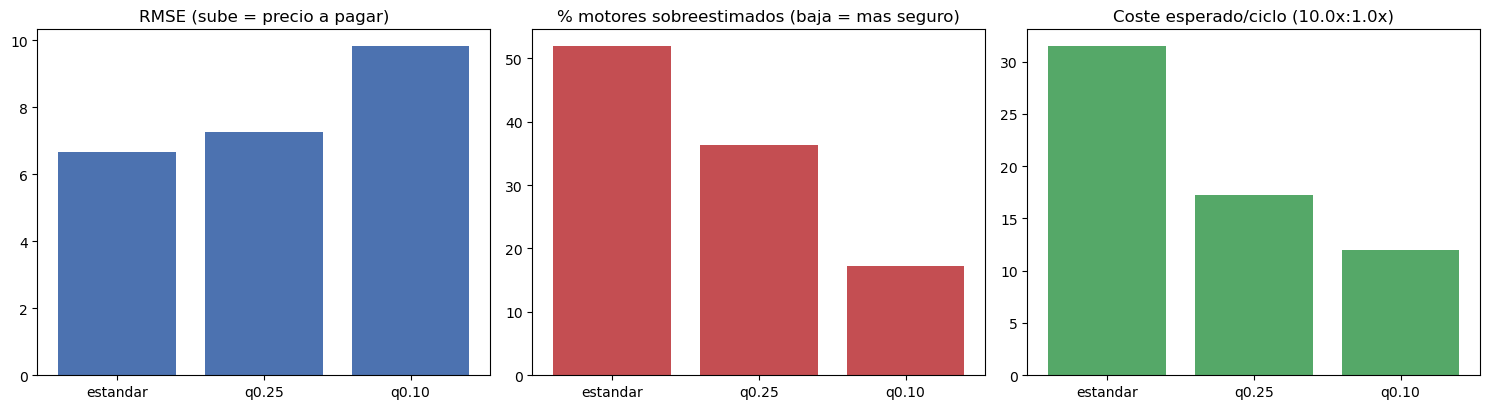

Modelo de menor coste esperado segun el ratio de coste (sobreestimar : subestimar):
  ratio |  estandar |     q0.25 |     q0.10 | GANADOR
     2x |     7.844 |     6.754 |     8.020 | q0.25
     5x |    16.553 |    10.612 |     9.409 | q0.10
    10x |    31.067 |    17.042 |    11.725 | q0.10
    20x |    60.097 |    29.903 |    16.357 | q0.10
    50x |   147.185 |    68.484 |    30.252 | q0.10

A mayor asimetria de coste (averia mucho mas cara que mantenimiento), mas conservador conviene ser.


In [7]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
m = resumen.index.tolist()
ax[0].bar(m, resumen.RMSE, color='#4C72B0'); ax[0].set_title('RMSE (sube = precio a pagar)')
ax[1].bar(m, resumen.pct_sobreestima, color='#C44E52'); ax[1].set_title('% motores sobreestimados (baja = mas seguro)')
ax[2].bar(m, resumen.coste_ciclo, color='#55A868'); ax[2].set_title(f'Coste esperado/ciclo ({COST_LATE}x:{COST_EARLY}x)')
plt.tight_layout(); plt.show()

# Sensibilidad: qué modelo minimiza el coste según la asimetría (sobreestimar : subestimar)
def coste_medio(d, c_late, c_early=1.0):
    return np.where(d > 0, c_late * d, c_early * (-d)).mean()

print('Modelo de menor coste esperado segun el ratio de coste (sobreestimar : subestimar):')
print(f'{"ratio":>7} | ' + ' | '.join(f'{mm:>9}' for mm in resumen.index) + ' | GANADOR')
for ratio in [2, 5, 10, 20, 50]:
    costs = {mm: coste_medio(errors_by_model[mm], ratio) for mm in resumen.index}
    win = min(costs, key=costs.get)
    print(f'{ratio:>6}x | ' + ' | '.join(f'{costs[mm]:9.3f}' for mm in resumen.index) + f' | {win}')
print('\nA mayor asimetria de coste (averia mucho mas cara que mantenimiento), mas conservador conviene ser.')

## 4. Resultados obtenidos y elección del modelo desplegado

| Modelo | RMSE | % sobreestima | NASA/ciclo | Coste/ciclo (10x) |
|---|---|---|---|---|
| Estándar | **6,67** | 52,0 | 0,760 | 31,50 |
| q0,25 | 7,28 | 36,3 | **0,748** | 17,28 |
| q0,10 | 9,84 | **17,2** | 1,124 | **11,99** |

**Tres lecturas, en orden de importancia:**

1. **El estándar es el mejor en RMSE y el peor donde importa:** sobreestima (el error peligroso)
   el 52% de las veces. Optimizar el error simétrico ignora que las dos direcciones del error no
   cuestan lo mismo.
2. **"Más conservador" no es siempre mejor:** el q0,10 minimiza la sobreestimación y el coste
   lineal, pero **empeora el score NASA** (1,124 vs 0,760) porque subestima tanto que acumula
   penalización — retirar motores demasiado pronto también tiene coste. Existe un punto óptimo.
3. **El q0,25 es el único que mejora a la vez la sobreestimación (52→36%) y el NASA** respecto al
   estándar. Es el equilibrio.

**Decisión: q0,25 como modelo principal desplegado; q0,10 como configuración de máxima seguridad**
para operadoras con asimetría de coste muy alta (la sensibilidad por ratios 2x–50x da la regla de
decisión completa). Estos modelos, guardados con joblib, son exactamente los que servirá la
arquitectura de streaming (Fase 4).